<a href="https://colab.research.google.com/github/elviakiran-miranda-hue/BUS4118S26/blob/dev/ML_exercise_xtra_credit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import pandas as pd

# Load dataset
df = pd.read_csv('/content/sample_data/Cleaned_Median_Home_Prices.csv')

# Display the first few rows of the DataFrame
print("First 5 rows of the DataFrame:")
print(df.head())

# Check the data types of each column
print("\nDataFrame Info:")
df.info()

# Check for any missing values
print("\nMissing values per column:")
print(df.isnull().sum())

First 5 rows of the DataFrame:
   Mon-Yr      CA  San Francisco  Santa Clara  Santa Cruz  Sonoma  \
0  Jan-90  194952         287499       271840    250000.0  174022   
1  Feb-90  196273         300877       273100    261607.0  180294   
2  Mar-90  194856         290151       275500    260577.0  178823   
3  Apr-90  196111         288725       274660    255263.0  184117   
4  May-90  195281         282626       266670    262500.0  185844   

   S.F. Bay Area  
0         227366  
1         234739  
2         235337  
3         233178  
4         235881  

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 432 entries, 0 to 431
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Mon-Yr         432 non-null    object 
 1   CA             432 non-null    int64  
 2   San Francisco  432 non-null    int64  
 3   Santa Clara    432 non-null    int64  
 4   Santa Cruz     431 non-null    float64
 5   Sonoma

In [8]:
import numpy as np

# Rename columns for clarity based on the task requirement
df = df.rename(columns={'Mon-Yr': 'month', 'CA': 'sales'})

# Convert 'month' column to datetime objects
df['month'] = pd.to_datetime(df['month'], format='%b-%y')

# Handle missing values in 'Santa Cruz' by filling with the median
df['Santa Cruz'].fillna(df['Santa Cruz'].median(), inplace=True)

# Display the updated DataFrame info and check for missing values again
print("\nDataFrame Info after renaming and type conversion:")
df.info()
print("\nMissing values per column after handling:")
print(df.isnull().sum())
print("\nFirst 5 rows of the DataFrame after preprocessing:")
print(df.head())


DataFrame Info after renaming and type conversion:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 432 entries, 0 to 431
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   month          432 non-null    datetime64[ns]
 1   sales          432 non-null    int64         
 2   San Francisco  432 non-null    int64         
 3   Santa Clara    432 non-null    int64         
 4   Santa Cruz     432 non-null    float64       
 5   Sonoma         432 non-null    int64         
 6   S.F. Bay Area  432 non-null    int64         
dtypes: datetime64[ns](1), float64(1), int64(5)
memory usage: 23.8 KB

Missing values per column after handling:
month            0
sales            0
San Francisco    0
Santa Clara      0
Santa Cruz       0
Sonoma           0
S.F. Bay Area    0
dtype: int64

First 5 rows of the DataFrame after preprocessing:
       month   sales  San Francisco  Santa Clara  Santa Cruz  Sonoma  \
0 

/tmp/ipython-input-1375041564.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Santa Cruz'].fillna(df['Santa Cruz'].median(), inplace=True)


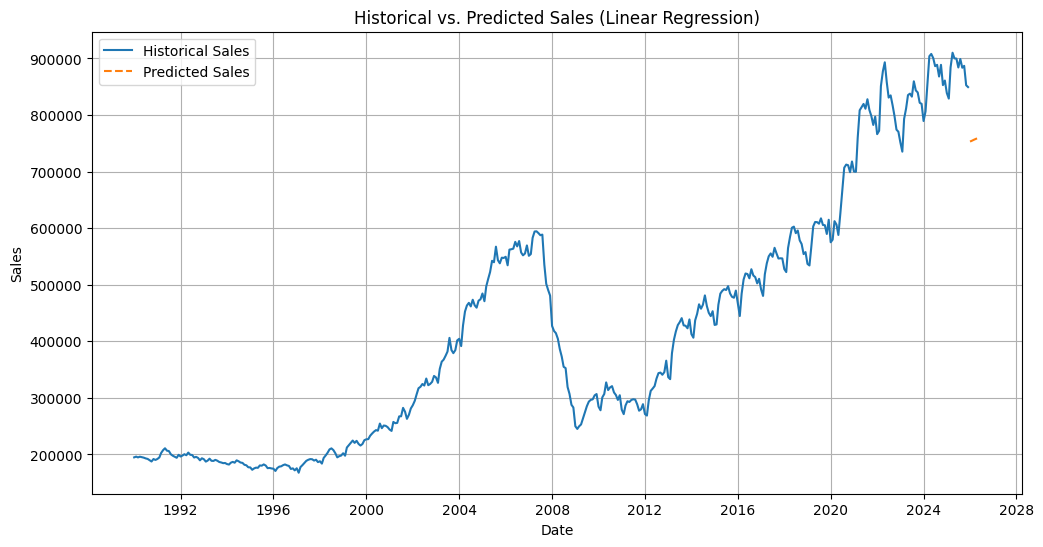

In [5]:
import pandas as pd
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# Create a numerical representation for the 'month' column
# This assumes the months are equally spaced, which is true for monthly data.
# We'll use the elapsed number of months from the first month as the numerical feature.
df['month_num'] = (df['month'].dt.year - df['month'].dt.year.min()) * 12 + df['month'].dt.month - df['month'].dt.month.min()

# Define features (X) and target (y)
X = df[['month_num']]
y = df['sales']

# Train the model
model = LinearRegression()
model.fit(X, y)

# Predict for next 6 months
# Determine the numerical values for the next 6 months
last_month_num = df['month_num'].max()
future_month_nums = pd.DataFrame({'month_num': range(last_month_num + 1, last_month_num + 7)})
predictions = model.predict(future_month_nums)

# Plot results
plt.figure(figsize=(12, 6))
plt.plot(df['month'], y, label='Historical Sales')

# To plot predictions against actual dates, we need to convert future_month_nums back to datetime objects
# Get the last historical date
last_date = df['month'].max()
# Generate future dates by adding months to the last historical date
future_dates = [last_date + pd.DateOffset(months=i) for i in range(1, 7)]

plt.plot(future_dates, predictions, label='Predicted Sales', linestyle='--')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.title('Historical vs. Predicted Sales (Linear Regression)')
plt.legend()
plt.grid(True)
plt.show()